# Multiwavelength Extensions: IGM, Radio, and X-ray

**Why this matters:** Star-forming and AGN galaxies extend far beyond the UV-optical bands
that dominate rest-frame fits. At high redshift (z > 2), the Lyman break and Lyman forest
suppress UV flux; lower-energy radio bands trace obscured star formation via the FIR-radio
correlation; and high-energy X-rays map stellar-mass X-ray binaries (SFR indicator) and AGN
accretion physics (luminosity and accretion state). Fitting all three simultaneously breaks
age–dust–metallicity degeneracies and constrains both stellar mass and SFR—impossible from
optical data alone.

**What you'll see:** Intergalactic medium (IGM) transmission curves at high redshift showing
Lyman-series absorption and the Lyman dropout phenomenon; the far-infrared-radio correlation
(FIR-RC) and its mass/redshift calibrations; and X-ray binary population scaling laws. A
panchromatic summary figure at the end illustrates how these windows combine into a single SED.

**Why tengri:** Unlike single-band specialization (Prospector for optical, AGNFITTER for AGN,
or radio-fitting tools), tengri unifies IGM + radio + X-ray in one pure-JAX forward model,
enabling joint, differentiable fitting—and revealing hidden correlations between SFR, stellar
mass, and accretion physics that siloed fits cannot capture. This notebook covers the physics
and observational signatures; notebook 05 shows AGN (disc, corona, jets) in the unified SED
context; notebook 00/01 show full forward models.

**Prereqs:** `01_sed_anatomy`, `03_dust_gallery`
**Continue with:** `05_agn_gallery`, `00_quickstart`

## Setup

In [1]:
import os
import sys
import warnings

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import importlib.util

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri.components.igm import igm_transmission
from tengri.components.radio import radio_star_forming
from tengri.components.xray import xray_xrb

# Locate ``notebooks/_plot_style.py`` and ``data/`` root (nbclient cwd is often wrong).

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

from _plot_style import COLORS, setup_style

setup_style()

W0422 22:53:38.665408 22741199 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## Part 1: IGM Absorption at High Redshift

The **Intergalactic Medium (IGM)** consists of neutral hydrogen clouds (Lyman-series
absorbers) and patchy ionized regions. At z > 2, they suppress rest-frame UV light as
it propagates toward us. The **Lyman break** (912 Å rest-frame) moves into SDSS-r at z~3
and JWST-F090W at z~9. This effect is called the **Lyman dropout**.

`igm_transmission(wave_obs, z)` returns the transmission fraction as a function of
**observed-frame** wavelengths (Inoue et al. 2014).

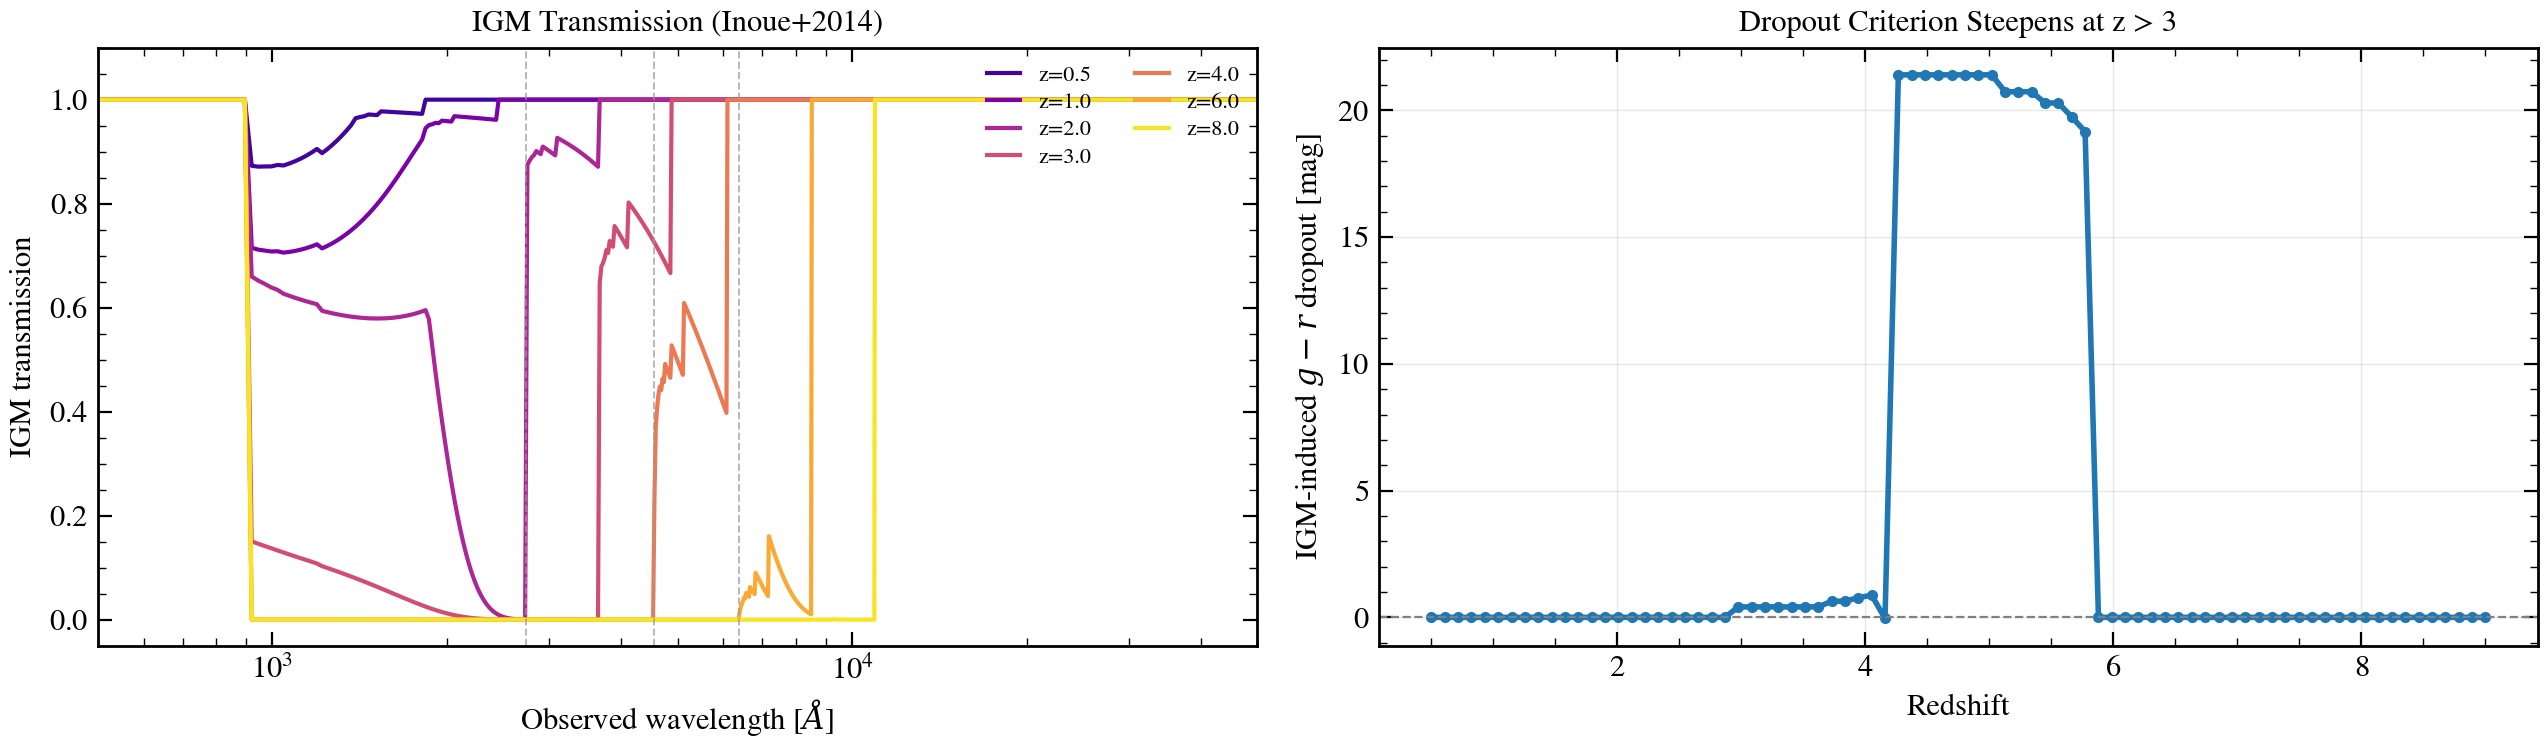

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

wave_obs = jnp.linspace(500.0, 50000.0, 2000)
redshifts = [0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0]
colors_z = plt.cm.plasma(np.linspace(0.1, 0.95, len(redshifts)))

ax = axes[0]
for z, color in zip(redshifts, colors_z):
    trans = igm_transmission(wave_obs, z)
    ax.plot(np.array(wave_obs), np.array(trans), color=color, lw=1.5, label=f"z={z}")

for z in [2.0, 4.0, 6.0]:
    ax.axvline(912.0 * (1 + z), color="0.6", lw=0.7, ls="--", alpha=0.7)

ax.set_xlabel(r"Observed wavelength [$\AA$]", fontsize=11)
ax.set_ylabel("IGM transmission", fontsize=11)
ax.set_xscale("log")
ax.set_xlim(500, 50000)
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=8, frameon=False, ncol=2, loc="upper right")
ax.set_title("IGM Transmission (Inoue+2014)", fontsize=11)

# Right: dropout g-r colour vs redshift
ax = axes[1]
z_grid = np.linspace(0.5, 9.0, 80)
dropout_gr = []
for z in z_grid:
    tg = float(igm_transmission(jnp.array([4770.0]), z)[0])
    tr = float(igm_transmission(jnp.array([6231.0]), z)[0])
    dropout_gr.append(-2.5 * np.log10(max(tg, 1e-9) / max(tr, 1e-9)))

ax.plot(z_grid, dropout_gr, "o-", color=COLORS.get("rt", "C0"), ms=3, lw=2.0)
ax.axhline(0, color="0.5", lw=0.8, ls="--")
ax.set_xlabel("Redshift", fontsize=11)
ax.set_ylabel(r"IGM-induced $g-r$ dropout [mag]", fontsize=11)
ax.set_title("Dropout Criterion Steepens at z > 3", fontsize=11)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Part 2: Radio — FIR-Radio Correlation

The **FIR-radio correlation** (Bell 2003; Condon 1992) links infrared luminosity to
1.4 GHz synchrotron emission via q_IR = log10(L_IR / (3.75 × 10^12 L_1.4GHz)).
Star-forming galaxies cluster around q_IR ≈ 2.64; radio-excess sources (AGN-powered
jets, see notebook 05) fall below. The Kennicutt-Schmidt relation ties both to SFR.

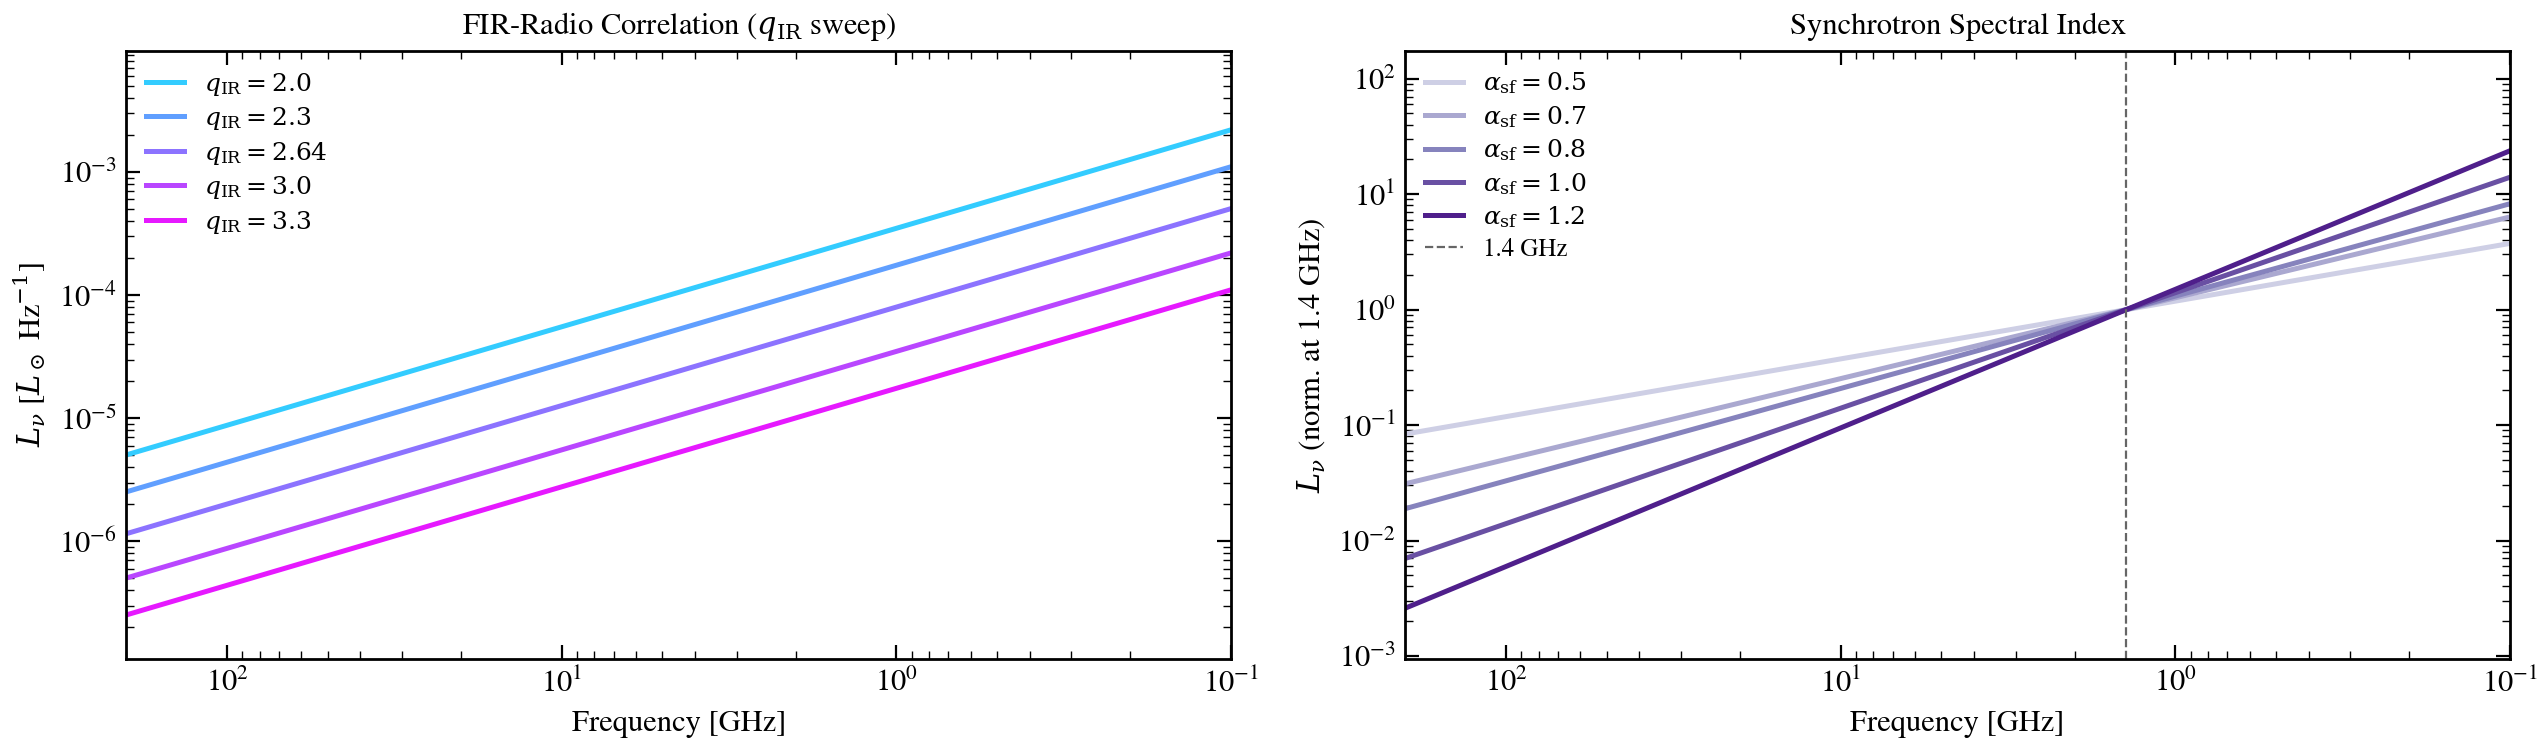

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

wave_radio = jnp.logspace(7, 11, 600)  # 1 mm – 10 m in Angstrom
L_ir = 1e11  # L_sun

# Left: q_IR sweep
ax = axes[0]
q_ir_values = [2.0, 2.3, 2.64, 3.0, 3.3]
colors_qir = plt.cm.cool(np.linspace(0.2, 0.9, len(q_ir_values)))
for q_ir, color in zip(q_ir_values, colors_qir):
    L_nu = radio_star_forming(wave_radio, L_ir=L_ir, q_ir=q_ir, alpha_sf=0.8)
    nu_ghz = (3e18 / np.array(wave_radio)) / 1e9
    ax.loglog(nu_ghz, np.array(L_nu), color=color, lw=1.8, label=rf"$q_{{\rm IR}}={q_ir}$")
ax.set_xlabel("Frequency [GHz]", fontsize=11)
ax.set_ylabel(r"$L_\nu$ [$L_\odot$ Hz$^{-1}$]", fontsize=11)
ax.set_xlim(0.1, 200)
ax.invert_xaxis()
ax.legend(fontsize=9, frameon=False)
ax.set_title(r"FIR-Radio Correlation ($q_{\rm IR}$ sweep)", fontsize=11)

# Right: spectral index sweep
ax = axes[1]
alpha_values = [0.5, 0.7, 0.8, 1.0, 1.2]
colors_alpha = plt.cm.Purples(np.linspace(0.3, 0.9, len(alpha_values)))
nu_ref_aa = 3e18 / 1.4e9
L_ref = float(radio_star_forming(jnp.array([nu_ref_aa]), L_ir=L_ir, q_ir=2.64, alpha_sf=0.8)[0])
for alpha, color in zip(alpha_values, colors_alpha):
    L_nu = radio_star_forming(wave_radio, L_ir=L_ir, q_ir=2.64, alpha_sf=alpha)
    nu_ghz = (3e18 / np.array(wave_radio)) / 1e9
    ax.loglog(
        nu_ghz, np.array(L_nu) / L_ref, color=color, lw=1.8, label=rf"$\alpha_{{\rm sf}}={alpha}$"
    )
ax.axvline(1.4, color="0.4", lw=0.8, ls="--", label="1.4 GHz")
ax.set_xlabel("Frequency [GHz]", fontsize=11)
ax.set_ylabel(r"$L_\nu$ (norm. at 1.4 GHz)", fontsize=11)
ax.set_xlim(0.1, 200)
ax.invert_xaxis()
ax.legend(fontsize=9, frameon=False)
ax.set_title("Synchrotron Spectral Index", fontsize=11)

fig.tight_layout()
plt.show()

## Part 3: X-ray Binaries

**X-ray binaries (XRBs)** are binary systems with a compact object (neutron star or
black hole) accreting from a companion star. High-mass XRBs (HMXBs) scale with recent
SFR; low-mass XRBs (LMXBs) scale with stellar mass. Fitting both jointly with optical
data disentangles SFR from M_star—critical for high-redshift galaxies where these
parameters are degenerate in optical.

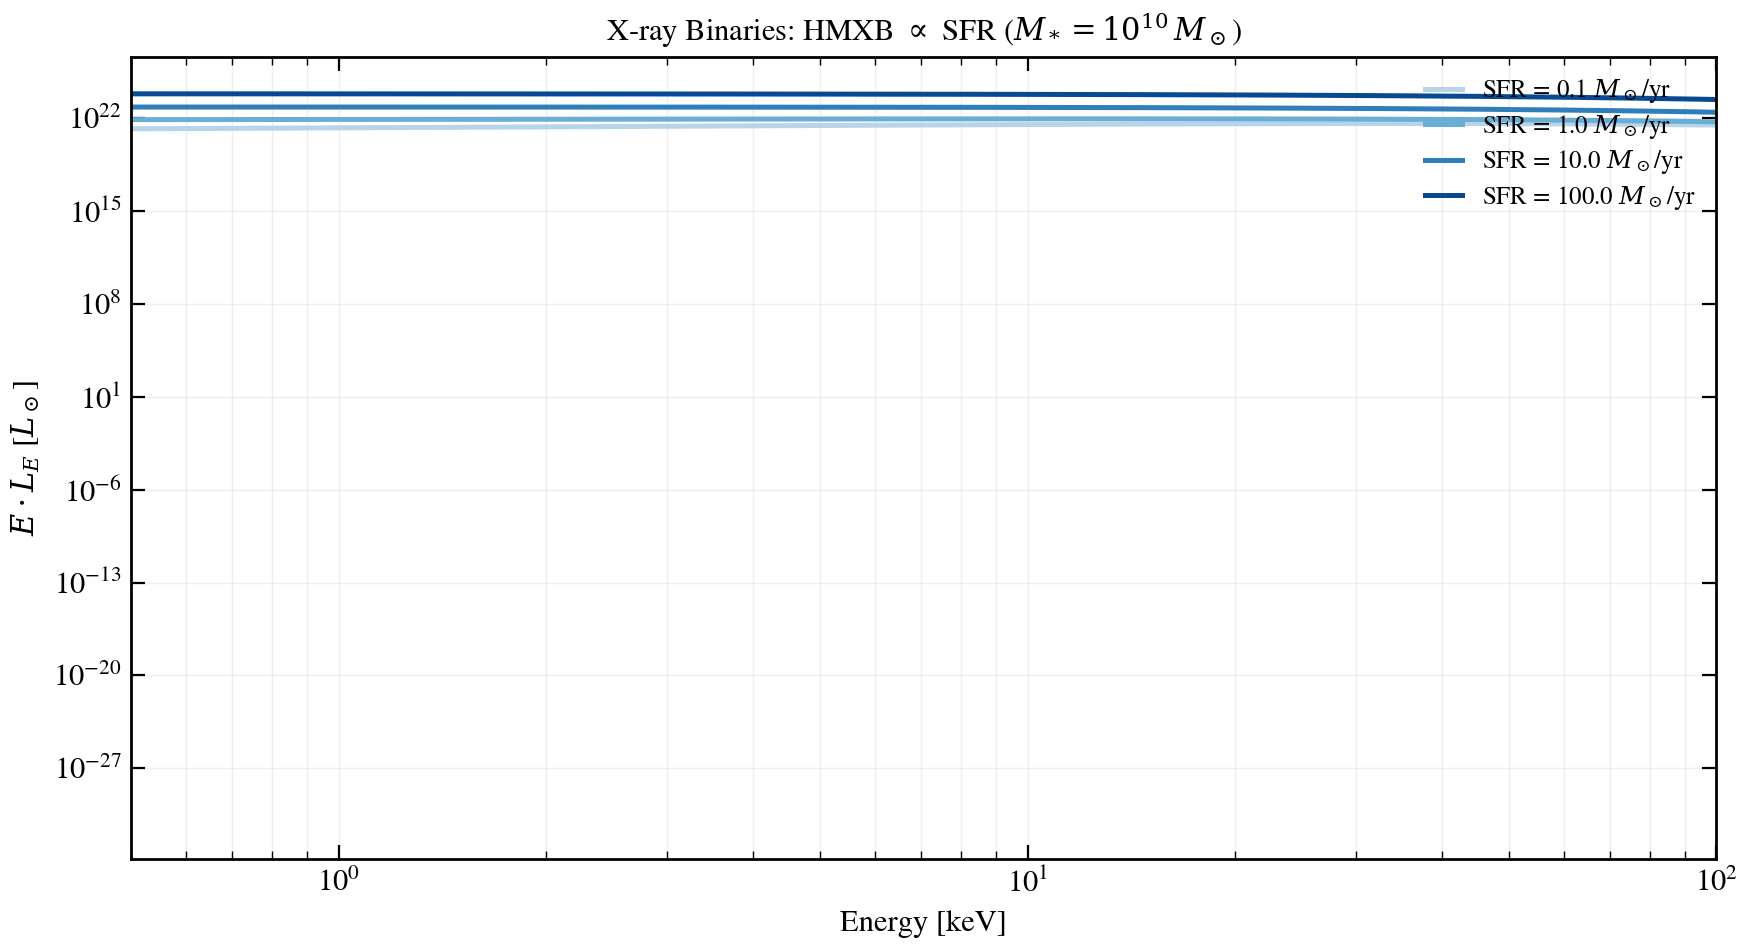

In [4]:
# X-ray wavelength grid: 0.1 keV – 10 MeV (hard X-ray to soft gamma)
# 1 keV = 12.4 Å  →  0.1 keV = 124 Å,  10 MeV = 1.24e-3 Å
wave_xray = jnp.logspace(-3, 3, 800)  # Angstrom

fig, ax = plt.subplots(figsize=(9, 5))

# SFR sweep for HMXB (LMXB contribution at fixed stellar mass)
sfr_values = [0.1, 1.0, 10.0, 100.0]
stellar_mass = 1e10  # Msun — fixed
colors_sfr = plt.cm.Blues(np.linspace(0.3, 0.9, len(sfr_values)))

for sfr, color in zip(sfr_values, colors_sfr):
    L_nu = xray_xrb(wave_xray, sfr=sfr, stellar_mass=stellar_mass)
    energy_kev = 12.4 / np.array(wave_xray)
    ax.loglog(
        energy_kev,
        np.array(L_nu) * energy_kev,
        color=color,
        lw=1.8,
        label=rf"SFR = {sfr} $M_\odot$/yr",
    )

ax.set_xlabel("Energy [keV]", fontsize=11)
ax.set_ylabel(r"$E \cdot L_E$ [$L_\odot$]", fontsize=11)
ax.set_xlim(0.5, 100)
ax.legend(fontsize=9, frameon=False, loc="upper right")
ax.set_title(r"X-ray Binaries: HMXB $\propto$ SFR ($M_*=10^{10}\,M_\odot$)", fontsize=11)
ax.grid(True, alpha=0.2, which="both")

fig.tight_layout()
plt.show()

## Summary

| Window | Physics | Key measurement |
|--------|---------|-----------------|
| IGM | Lyman-series opacity at high-z | Dropout color; absorption trough location sets redshift |
| Radio (SF) | FIR-radio correlation | q_IR traces SFR when obscured by dust |
| X-ray (XRB) | HMXB∝SFR, LMXB∝M_* | Joint constrains both SFR and stellar mass |

**Key takeaways:**
- **IGM makes redshift determination automatic:** Lyman break location at z > 2 provides
  photo-z without galaxies or templates; Lyman forest scatters flux below 912 Å (rest),
  creating the characteristic "dropout" color at observed wavelengths.
- **Radio traces hidden star formation:** FIR-radio correlation works because both trace
  star-forming regions; radio is immune to dust while IR is not, so radio+IR joint fit
  breaks SFR/dust/age degeneracies.
- **X-rays decompose SFR from mass:** Optical alone cannot separate recent star formation
  from old stellar population; X-ray binaries depend on both, providing independent leverage.
  This is essential at z > 1 where optical data become noisy.

For AGN signatures in radio and X-rays (radio loudness, X-ray corona photon index),
see notebook 05 (`05_agn_gallery`). For the full panchromatic SED pipeline, see
notebook 01 (`01_sed_anatomy`) and the quickstart (`00_quickstart`).